# Limit Order Book - Parameter Estimation
This notebook follows the methods found in (this paper) in order to estimate parameters of interest and simulate the dynamics of a Limit Order Book (LOB). We will estimate parameters including *limit, market,* and *cancellation order arrival rates*, on  containing 1 hour of SPY (price info) trading data containing 50 levels. We will then compare the results of our simulation to the analytical solutions proposed by the paper.

## Load Lobster Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares # to test power law hypothesis

In [2]:
levels = 50
nms = []
for i in range(levels):
    curr_lvl = [
        f'Ask Price {i + 1}',
        f'Ask Size {i + 1}',
        f'Bid Price {i + 1}',
        f'Bid Size {i + 1}',
    ]
    nms.extend(curr_lvl)
spy = pd.read_csv(
    "LOBSTER_SampleFile_SPY_2012-06-21_50/SPY_2012-06-21_34200000_37800000_orderbook_50.csv",
    names=nms,
    na_values= [-9999999999]
)

cols = [
    "Time (sec)",
    "Event Type",
    "Order ID",
    "Size",
    "Price",
    "Direction",
]
spy_msg = pd.read_csv("LOBSTER_SampleFile_SPY_2012-06-21_50/SPY_2012-06-21_34200000_37800000_message_50.csv", names=cols)
spy_msg

data = spy
data[cols] = spy_msg[cols]
data = data[data['Event Type'] != 5].reset_index(drop=True)
data.head()

,Ask Price 1,Ask Size 1,Bid Price 1,Bid Size 1,Ask Price 2,Ask Size 2,Bid Price 2,Bid Size 2,Ask Price 3,Ask Size 3,...,Ask Price 50,Ask Size 50,Bid Price 50,Bid Size 50,Time (sec),Event Type,Order ID,Size,Price,Direction
0,1356500,3400,1356300,8800,1356600,17200,1356200,17600,1356700,13500,...,1629000,2800,1086000.0,3700,34200.005929,1,16114346,1300,1356500,-1
1,1356500,3400,1356300,8800,1356600,17200,1356200,17600,1356700,13500,...,1629000,2800,1086000.0,3700,34200.005942,1,16114355,1300,1355000,1
2,1356500,3400,1356300,8800,1356600,18500,1356200,17600,1356700,13500,...,1629000,2800,1086000.0,3700,34200.006946,1,16114998,1300,1356600,-1
3,1356500,3400,1356300,8800,1356600,18500,1356200,17600,1356700,13500,...,1629000,2800,1086000.0,3700,34200.007034,1,16115038,1300,1354900,1
4,1356500,3400,1356300,8800,1356600,18500,1356200,17600,1356700,14800,...,1629000,2800,1086000.0,3700,34200.007882,1,16115494,1300,1356700,-1


In [3]:
# time duration (in seconds)
T = round(data['Time (sec)'].iloc[-1]  - data['Time (sec)'].iloc[0])
T

3600

## Unit Size Calculation

Compute the average size of market orders, $S_m$, of limit orders, $S_l$, and of canceled orders, $S_c$, and
choose the size unit to be the average size of a limit order, $S_l$; a block of orders of size $S_l$ is counted
as one event.

In [4]:
S_l = data[data['Event Type'] == 1]['Size'].mean()
S_c = data[((data['Event Type'] == 2) | (data['Event Type'] == 3))]['Size'].mean()
S_m = data[data['Event Type'] == 4]['Size'].mean()

S_m, S_l, S_c

(np.float64(289.8940283675129),
 np.float64(539.5606099212555),
 np.float64(547.1071281756145))

The limit order arrival rate function can be estimated by
$$ \hat \lambda (i) = \frac{N_l(i)} T,$$
where $N_l(i)$ is the total number of limit orders that arrived at a distance $i$ from the opposite best
quote. $N_l(i)$ is obtained by enumerating the number of times that a quote increases in size at a
distance of $i$ ticks from the opposite best quote.

***Note:** $T = 3600$ (seconds), $i = 50$ (levels)*

In [5]:
quote_jumps = data[[x for x in data.columns if 'Size ' in x]]
quote_jump_size = (quote_jumps > quote_jumps.shift(1)) * (quote_jumps - quote_jumps.shift(1)) // S_l
N_l = quote_jump_size.sum(skipna=True)
N_l.name = 'quote_jumps'
N_l

Ask Size 1     88347.0
Bid Size 1     87293.0
Ask Size 2     41469.0
Bid Size 2     39951.0
Ask Size 3     33187.0
                ...   
Bid Size 48     4278.0
Ask Size 49     1680.0
Bid Size 49     2895.0
Ask Size 50     1809.0
Bid Size 50     2530.0
Name: quote_jumps, Length: 100, dtype: float64

## Test with combined buy & sell rates

In [39]:
# index flags to group bid+ask level data
grouped_levels = [int(x[-2:]) for x in N_l.index]

In [40]:
lambda_hat = N_l.groupby(grouped_levels).sum() / T
lambda_hat

1     48.788889
2     22.616667
3     17.777222
4     11.072222
5      7.398333
6      7.131667
7      6.843889
8      6.968889
9      6.580278
10     5.500833
11     5.113056
12     4.815000
13     4.777222
14     4.714444
15     3.985556
16     3.578056
17     3.764167
18     4.286944
19     4.291667
20     3.551111
21     2.600556
22     2.082222
23     1.676111
24     1.615833
25     1.486944
26     1.246389
27     1.195833
28     1.226111
29     1.253056
30     1.182778
31     1.103056
32     1.143889
33     1.081389
34     1.010556
35     1.171389
36     1.457778
37     1.645556
38     1.797500
39     1.660833
40     1.544722
41     1.697222
42     1.617222
43     1.549722
44     1.546389
45     1.588056
46     1.648889
47     1.749444
48     1.557500
49     1.270833
50     1.205278
Name: quote_jumps, dtype: float64

Text(0.5, 1.0, 'Estimated (Bid & Ask) Limit order Arrival Rates for all levels')

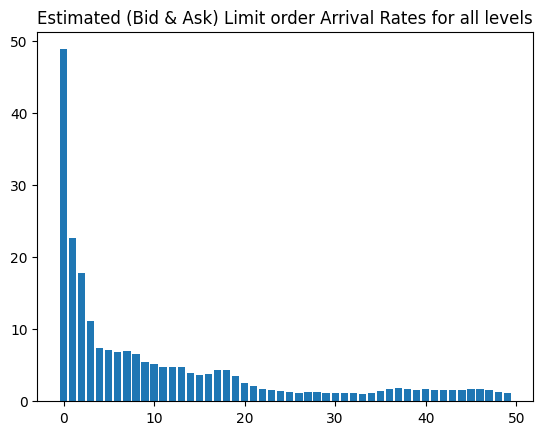

In [10]:
plt.bar(range(50),lambda_hat)
plt.title('Estimated (Bid & Ask) Limit order Arrival Rates for all levels')

### Extrapolating limit arrival rates

Zovko and Farmer (2002) or Bouchaud et al. (2002) suggest extrapolating by fitting a power law function of the form
$$\hat \lambda(i) = \frac k {i ^\alpha}$$

In [11]:
def fun_power_law(x):
    """Residuals based on least squares fit of first 5 limit order rates"""
    lambda_hat_i = lambda i: x[0] / (i ** x[1])
    return np.array([lambda_hat_i(i + 1) for i in range(5)]) - lambda_hat[0:5].to_numpy()
x0_lambda = np.array([1, 1])
res_1 = least_squares(fun_power_law, x0_lambda)
np.array([res_1.x[0] / ((i+1) ** res_1.x[1]) for i in range(10)])

array([48.77897082, 23.50926441, 15.33944604, 11.33040537,  8.95769569,
        7.39292131,  6.28520013,  5.46074448,  4.82377141,  4.31720541])

Text(0.5, 1.0, 'First 10 Estimated vs Extrapolated (Bid & Ask) Limit order Arrival Rates')

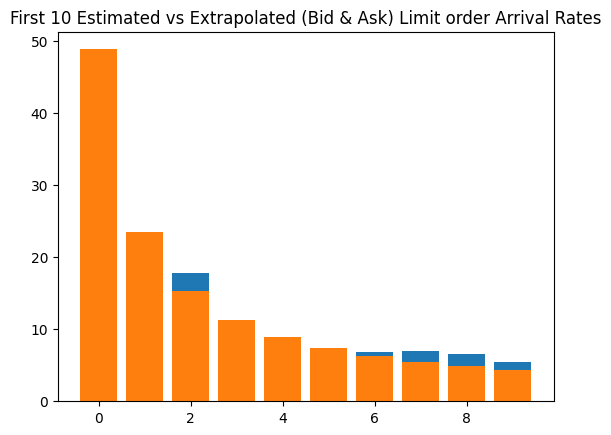

In [12]:
plt.bar(np.arange(10), lambda_hat[0:10])
plt.bar(np.arange(10), [res_1.x[0] / ((i+1) ** res_1.x[1]) for i in range(10)])
plt.title('First 10 Estimated vs Extrapolated (Bid & Ask) Limit order Arrival Rates')

## Estimating arrival rate of market orders

We can estimate market order arrivals by
$$\hat \mu = \frac{N_m}{T}\frac{S_m}{S_l}$$
where $T$ is the length of our sample (in seconds) and $N_m$ is the number of market orders. **Note** that we *ignore hidden orders*.

In [13]:
# Execution of a (visible) limit order is equivalent of placing & filling a market order
N_m = data[data['Event Type'] == 4]['Size'].sum() / S_m
N_m

np.float64(33207.0)

In [14]:
mu_hat = (N_m / T) * (S_m / S_l)
mu_hat

np.float64(4.955941527539578)

## Estimating Cancellation Rates

Since the cancellation rate in our model is proportional to the number of orders at a particular price level, in order to estimate the cancellation rate we first need to estimate the steady state shape of the order book, $Q_i$, which is the average number of orders at a distance of $i$ ticks from the opposite best quote.

If $M$ is the number of quote rows *(roughly 1.1 million in our case)* and $S^B_i(j)$ the **number of shares bid** at a distance of $i$ ticks from the ask on the $j^{th}$ row, for $1 \le j \le M$, we have
$$Q^B_i = \frac 1 {S_l} \frac 1 M \sum_{j=1}^M S_i^B(j)$$

The vector $Q^A_i$ is obtained analogously and $Q_i$ is the average of $Q^A_i$ and $Q^B_i$.

In [19]:
#Bids = data[data['Direction'] == 1][[x for x in data.columns if 'Ask' not in x]].reset_index(drop=True)
#Asks = data[data['Direction'] == -1][[x for x in data.columns if 'Bid' not in x]].reset_index(drop=True)
#Bids

In [42]:
AB_Q_i = data[[x for x in data.columns if 'Size ' in x]].mean() / S_l
Q_i = AB_Q_i.groupby([int(x[-2:]) for x in AB_Q_i.index]).mean()
Q_i

1     13.857226
2     20.557688
3     27.385092
4     30.704812
5     30.009863
6     27.117480
7     23.708949
8     19.584221
9     15.570604
10    12.599175
11    10.962708
12     9.814062
13     8.726614
14     7.050992
15     5.500876
16     4.672895
17     4.221696
18     4.050709
19     3.771669
20     3.349614
21     2.757535
22     2.343887
23     1.976958
24     1.849552
25     1.694450
26     1.495887
27     1.437618
28     1.383269
29     1.246615
30     1.159765
31     1.163615
32     1.150268
33     1.075313
34     1.123753
35     1.220892
36     1.317229
37     1.475216
38     1.429361
39     1.375165
40     1.199613
41     1.299723
42     1.216610
43     1.202011
44     1.295007
45     1.291248
46     1.242016
47     1.312652
48     1.100583
49     1.059434
50     1.018380
dtype: float64

An estimator for the cancellation rate function is then given by
$$\hat \theta(i) = \frac{N_c(i)}{TQ_i} \frac {S_c}{S_l}$$

where $i$ is the number of levels. $N_c(i)$ is obtained by counting the number of times
that a quote decreases in size at a distance of i ticks from the opposite best quote, *excluding decreases due to market orders*.
### Remark
The paper uses $i \le i \le 5$ and extrapolates using $\hat \theta(i) = \hat \theta(5)$ for $i > 5$. *(Hence using the power law to fit limit order rates for levels 6-10)*.

In [51]:
cancellation_size = ((quote_jumps < quote_jumps.shift(1)) * (quote_jumps.shift(1) - quote_jumps))[(data['Event Type'] == 2) | (data['Event Type'] == 3)] / S_l
N_c_i = (cancellation_size.sum()).groupby(grouped_levels).sum()
N_c_i

1     284291.979769
2      77512.359559
3      45634.231905
4      44700.433198
5      22260.514906
6      12770.596803
7      10219.584044
8      10684.781087
9      10774.172342
10      8261.707615
11      6834.344339
12      7013.056421
13      5792.891369
14      6411.420583
15      5255.511518
16      3950.788773
17      4318.261854
18      5070.477625
19      5012.348845
20      4023.825980
21      2816.350883
22      2273.077347
23      1960.589748
24      1441.157834
25      1441.873231
26      1299.720526
27      1288.885784
28      1057.946020
29      1093.365581
30      1089.025013
31       763.519413
32       864.384819
33       866.929482
34       758.515341
35       648.481363
36       609.227201
37       858.467041
38       846.735272
39      1052.650971
40       615.708400
41       835.212934
42       842.174154
43       765.617416
44       705.081122
45       943.995893
46       836.539940
47       846.498042
48      1165.209225
49       742.930438
50       806.339440


In [52]:
theta_hat = np.multiply(N_c_i, 1/Q_i) * S_c / (S_l * T)
theta_hat

1     5.778538
2     1.062004
3     0.469360
4     0.410048
5     0.208930
6     0.132645
7     0.121409
8     0.153670
9     0.194898
10    0.184696
11    0.175594
12    0.201274
13    0.186973
14    0.256114
15    0.269099
16    0.238137
17    0.288106
18    0.352572
19    0.374315
20    0.338356
21    0.287671
22    0.273154
23    0.279331
24    0.219470
25    0.239678
26    0.244726
27    0.252523
28    0.215420
29    0.247037
30    0.264483
31    0.184816
32    0.211660
33    0.227080
34    0.190118
35    0.149606
36    0.130271
37    0.163907
38    0.166853
39    0.215605
40    0.144565
41    0.180999
42    0.194976
43    0.179404
44    0.153354
45    0.205916
46    0.189710
47    0.181638
48    0.298202
49    0.197517
50    0.223017
dtype: float64

Text(0.5, 1.0, 'Estimated (Bid & Ask) Limit order Cancellation Rates for all levels')

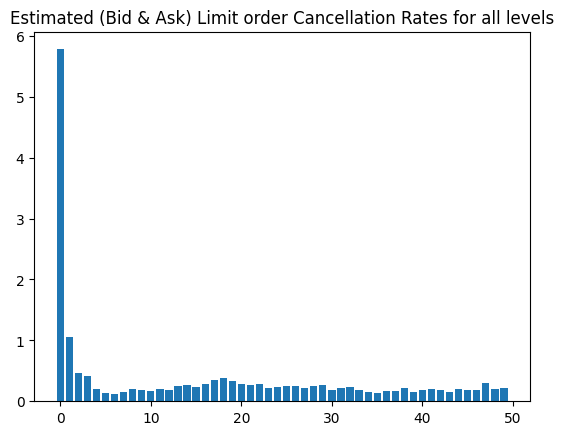

In [53]:
plt.bar(range(50),theta_hat)
plt.title('Estimated (Bid & Ask) Limit order Cancellation Rates for all levels')